In [ ]:
#Import Libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler


In [ ]:
#Loading DataSet
df=pd.read_csv("/content/Effectiveness of Listening to Lectures and Self-Study for Retention (2).csv")
df.head()

,Faculty,Year,Gender,Hr_SS,Hr_LL,Resources_SS,Study_method,Rem_LL,Rem_SS,Retain_SS_LL,Exam_recall,Challenge_LL,Challenge_SS,Long_term_retention,Combine_LM_SS,Conceptual_understanding_LL,Deeper_understanding_SS
0,Faculty of Humanities and Social Sciences,3rd Year,Female,6-10 hours,16-20 hours,YouTube Videos,Both equally,3,3,More from self-study,4,Difficulty remembering information after the l...,Time management,Both equally,Often,No,Agree
1,Faculty of Humanities and Social Sciences,3rd Year,Female,6-10 hours,11-15 hours,Online Courses,Self-study,3,4,More from self-study,5,Difficulty concentrating,Lack of focus,Self-study,Often,No,Agree
2,Faculty of Humanities and Social Sciences,3rd Year,Female,11-15 hours,16-20 hours,YouTube Videos,Self-study,3,5,More from self-study,5,Difficulty remembering information after the l...,Time management,Self-study,Sometimes,Maybe,Agree
3,Faculty of Humanities and Social Sciences,3rd Year,Female,0-5 hours,0-5 hours,Online Courses,Listening to lectures,3,3,More from self-study,3,Difficulty concentrating,Lack of focus,Self-study,Often,Yes,Agree
4,Faculty of Humanities and Social Sciences,3rd Year,Female,11-15 hours,More than 20 hours,YouTube Videos,Both equally,4,5,More from lectures,4,Difficulty concentrating,Other,Both equally,Always,Yes,Neutral


# **Data Preprocessing**

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
print(missing_values)


Faculty                         0
Year                            0
Gender                          0
Hr_SS                           0
Hr_LL                           0
Resources_SS                    0
Study_method                    0
Rem_LL                          0
Rem_SS                          0
Retain_SS_LL                    0
Exam_recall                     0
Challenge_LL                    0
Challenge_SS                    0
Long_term_retention             0
Combine_LM_SS                   0
Conceptual_understanding_LL     0
Deeper_understanding_SS         0
dtype: int64


In [ ]:
# Removing duplicates
df.drop_duplicates(inplace=True)
df.head()

,Faculty,Year,Gender,Hr_SS,Hr_LL,Resources_SS,Study_method,Rem_LL,Rem_SS,Retain_SS_LL,Exam_recall,Challenge_LL,Challenge_SS,Long_term_retention,Combine_LM_SS,Conceptual_understanding_LL,Deeper_understanding_SS
0,Faculty of Humanities and Social Sciences,3rd Year,Female,6-10 hours,16-20 hours,YouTube Videos,Both equally,3,3,More from self-study,4,Difficulty remembering information after the l...,Time management,Both equally,Often,No,Agree
1,Faculty of Humanities and Social Sciences,3rd Year,Female,6-10 hours,11-15 hours,Online Courses,Self-study,3,4,More from self-study,5,Difficulty concentrating,Lack of focus,Self-study,Often,No,Agree
2,Faculty of Humanities and Social Sciences,3rd Year,Female,11-15 hours,16-20 hours,YouTube Videos,Self-study,3,5,More from self-study,5,Difficulty remembering information after the l...,Time management,Self-study,Sometimes,Maybe,Agree
3,Faculty of Humanities and Social Sciences,3rd Year,Female,0-5 hours,0-5 hours,Online Courses,Listening to lectures,3,3,More from self-study,3,Difficulty concentrating,Lack of focus,Self-study,Often,Yes,Agree
4,Faculty of Humanities and Social Sciences,3rd Year,Female,11-15 hours,More than 20 hours,YouTube Videos,Both equally,4,5,More from lectures,4,Difficulty concentrating,Other,Both equally,Always,Yes,Neutral


In [ ]:
# Remove Outliers
import numpy as np
import pandas as pd
from scipy import stats

# Select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Calculate Z-scores for numeric columns
z_scores = np.abs(stats.zscore(numeric_df))
threshold = 3

df = df[(z_scores < threshold).all(axis=1)]

# View the cleaned data
print(df)


                                        Faculty      Year  Gender  \
0     Faculty of Humanities and Social Sciences  3rd Year  Female   
1     Faculty of Humanities and Social Sciences  3rd Year  Female   
2     Faculty of Humanities and Social Sciences  3rd Year  Female   
3     Faculty of Humanities and Social Sciences  3rd Year  Female   
4     Faculty of Humanities and Social Sciences  3rd Year  Female   
..                                          ...       ...     ...   
99   Faculty of Management studies and Commerce  1st Year  Female   
100   Faculty of Humanities and Social Sciences  4th Year  Female   
101                                       Other  1st Year    Male   
102   Faculty of Humanities and Social Sciences  4th Year  Female   
103   Faculty of Humanities and Social Sciences  3rd Year  Female   

                Hr_SS                Hr_LL        Resources_SS  \
0            6-10 hours         16-20 hours     YouTube Videos   
1            6-10 hours         11-15 h

In [ ]:
df.head()

,Faculty,Year,Gender,Hr_SS,Hr_LL,Resources_SS,Study_method,Rem_LL,Rem_SS,Retain_SS_LL,Exam_recall,Challenge_LL,Challenge_SS,Long_term_retention,Combine_LM_SS,Conceptual_understanding_LL,Deeper_understanding_SS
0,Faculty of Humanities and Social Sciences,3rd Year,Female,6-10 hours,16-20 hours,YouTube Videos,Both equally,3,3,More from self-study,4,Difficulty remembering information after the l...,Time management,Both equally,Often,No,Agree
1,Faculty of Humanities and Social Sciences,3rd Year,Female,6-10 hours,11-15 hours,Online Courses,Self-study,3,4,More from self-study,5,Difficulty concentrating,Lack of focus,Self-study,Often,No,Agree
2,Faculty of Humanities and Social Sciences,3rd Year,Female,11-15 hours,16-20 hours,YouTube Videos,Self-study,3,5,More from self-study,5,Difficulty remembering information after the l...,Time management,Self-study,Sometimes,Maybe,Agree
3,Faculty of Humanities and Social Sciences,3rd Year,Female,0-5 hours,0-5 hours,Online Courses,Listening to lectures,3,3,More from self-study,3,Difficulty concentrating,Lack of focus,Self-study,Often,Yes,Agree
4,Faculty of Humanities and Social Sciences,3rd Year,Female,11-15 hours,More than 20 hours,YouTube Videos,Both equally,4,5,More from lectures,4,Difficulty concentrating,Other,Both equally,Always,Yes,Neutral


In [ ]:
#Summery Statistics
df.describe()

,Year,Rem_LL,Rem_SS,Exam_recall,Conceptual_understanding_LL,Deeper_understanding_SS,Faculty_Faculty of Computing,Faculty_Faculty of Engineering,Faculty_Faculty of Humanities and Social Sciences,Faculty_Faculty of Management studies and Commerce,...,Long_term_retention _Self-study,Combine_LM_SS_Never,Combine_LM_SS_Often,Combine_LM_SS_Rarely,Combine_LM_SS_Sometimes,Cluster_Agglomerative,Cluster_Hierarchical,Cluster_GMM,Best_Cluster_KMeans,Spectral_Cluster
count,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,...,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000
mean,1.764706,3.029412,3.833333,3.647059,0.598039,0.852941,0.019608,0.019608,0.549020,0.117647,...,0.392157,0.009804,0.294118,0.029412,0.421569,0.284314,1.686275,1.009804,0.666667,1.049020
std,0.706076,0.801680,0.784545,0.766205,0.774083,1.163786,0.139333,0.139333,0.500049,0.323781,...,0.490642,0.099015,0.457895,0.169792,0.496249,0.453315,0.466298,0.814413,0.473732,0.788248
min,0.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1.250000,3.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,2.000000,3.000000,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000,1.000000
75%,2.000000,3.000000,4.000000,4.000000,1.000000,2.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,2.000000,2.000000,1.000000,2.000000
max,3.000000,5.000000,5.000000,5.000000,2.000000,4.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,2.000000


In [ ]:
#To check the coloumn details
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102 entries, 0 to 103
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Faculty                       102 non-null    object
 1   Year                          102 non-null    object
 2   Gender                        102 non-null    object
 3   Hr_SS                         102 non-null    object
 4   Hr_LL                         102 non-null    object
 5   Resources_SS                  102 non-null    object
 6   Study_method                  102 non-null    object
 7   Rem_LL                        102 non-null    int64 
 8   Rem_SS                        102 non-null    int64 
 9   Retain_SS_LL                  102 non-null    object
 10  Exam_recall                   102 non-null    int64 
 11  Challenge_LL                  102 non-null    object
 12  Challenge_SS                  102 non-null    object
 13  Long_term_retention      

In [ ]:
# Endoding Data

import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Initialize label encoder
le = LabelEncoder()

# Columns that will use label encoding (ordinal variables)
label_encode_columns = ['Year', 'Conceptual_understanding_LL ', 'Deeper_understanding_SS  ']

# Apply Label Encoding
for col in label_encode_columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Columns that will use one-hot encoding (nominal variables)
one_hot_columns = ['Faculty', 'Gender', 'Hr_SS  ', 'Hr_LL ', 'Resources_SS', 'Study_method ',
                   'Retain_SS_LL  ', 'Challenge_LL  ', 'Challenge_SS',
                   'Long_term_retention ', 'Combine_LM_SS']

# Apply One-Hot Encoding using pandas
df_encoded = pd.get_dummies(df, columns=one_hot_columns, drop_first=True)

# View the first few rows of the encoded dataset
print(df_encoded.head())

   Year  Rem_LL  Rem_SS  Exam_recall  Conceptual_understanding_LL   \
0     2       3       3            4                             1   
1     2       3       4            5                             1   
2     2       3       5            5                             0   
3     2       3       3            3                             2   
4     2       4       5            4                             2   

   Deeper_understanding_SS    Faculty_Faculty of Computing  \
0                          0                         False   
1                          0                         False   
2                          0                         False   
3                          0                         False   
4                          2                         False   

   Faculty_Faculty of Engineering  \
0                           False   
1                           False   
2                           False   
3                           False   
4                    

In [ ]:
df_encoded.head()

,Year,Rem_LL,Rem_SS,Exam_recall,Conceptual_understanding_LL,Deeper_understanding_SS,Faculty_Faculty of Computing,Faculty_Faculty of Engineering,Faculty_Faculty of Humanities and Social Sciences,Faculty_Faculty of Management studies and Commerce,...,Challenge_SS_Lack of focus,Challenge_SS_Lack of motivation,Challenge_SS_Other,Challenge_SS_Time management,Long_term_retention _Listening to lectures,Long_term_retention _Self-study,Combine_LM_SS_Never,Combine_LM_SS_Often,Combine_LM_SS_Rarely,Combine_LM_SS_Sometimes
0,2,3,3,4,1,0,False,False,True,False,...,False,False,False,True,False,False,False,True,False,False
1,2,3,4,5,1,0,False,False,True,False,...,True,False,False,False,False,True,False,True,False,False
2,2,3,5,5,0,0,False,False,True,False,...,False,False,False,True,False,True,False,False,False,True
3,2,3,3,3,2,0,False,False,True,False,...,True,False,False,False,False,True,False,True,False,False
4,2,4,5,4,2,2,False,False,True,False,...,False,False,True,False,False,False,False,False,False,False


In [ ]:
# Scale/Normalize Numeric Columns
from sklearn.preprocessing import StandardScaler

# Select only numerical columns
numerical_columns = df_encoded.select_dtypes(include=['int64', 'float64']).columns

# Apply Standard Scaling
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_encoded[numerical_columns]), columns=numerical_columns)


# **EDA**

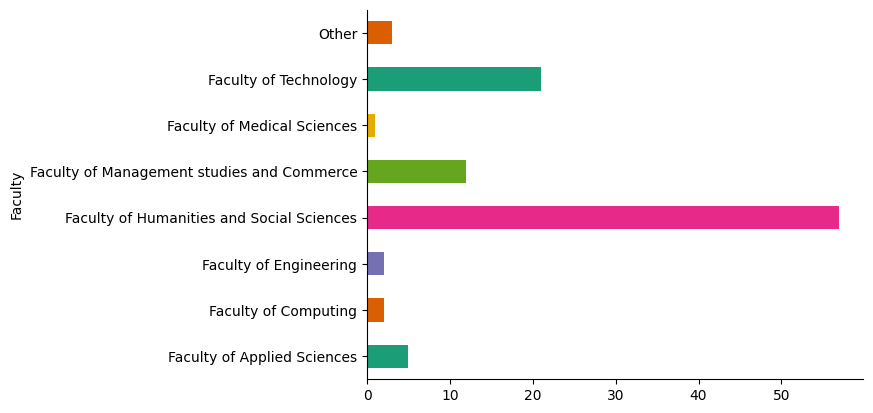

In [ ]:
# No.of Students per Faculty
from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('Faculty').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

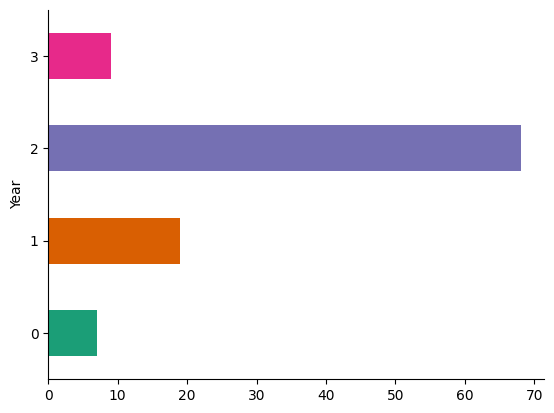

In [ ]:
# No.of Students per Academic year
from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('Year').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

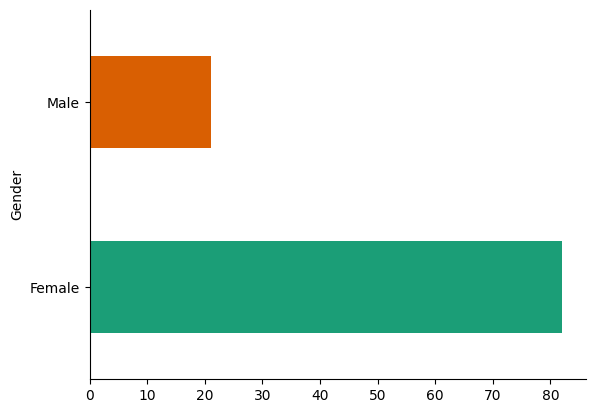

In [ ]:
# Gender
from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('Gender').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

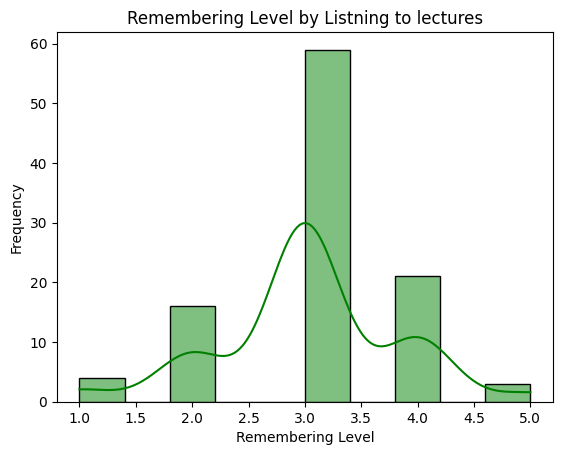

In [ ]:
# Remembering Level by Listning to lectures
sns.histplot(df['Rem_LL'], kde=True, color='green', bins=10)
plt.title("Remembering Level by Listning to lectures")
plt.xlabel("Remembering Level")
plt.ylabel("Frequency")
plt.show()

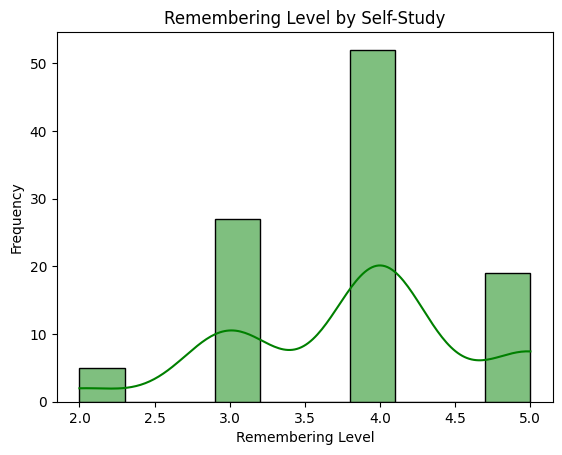

In [ ]:
#Remembering Level by Self-Study
sns.histplot(df['Rem_SS'], kde=True, color='green', bins=10)
plt.title("Remembering Level by Self-Study")
plt.xlabel("Remembering Level")
plt.ylabel("Frequency")
plt.show()

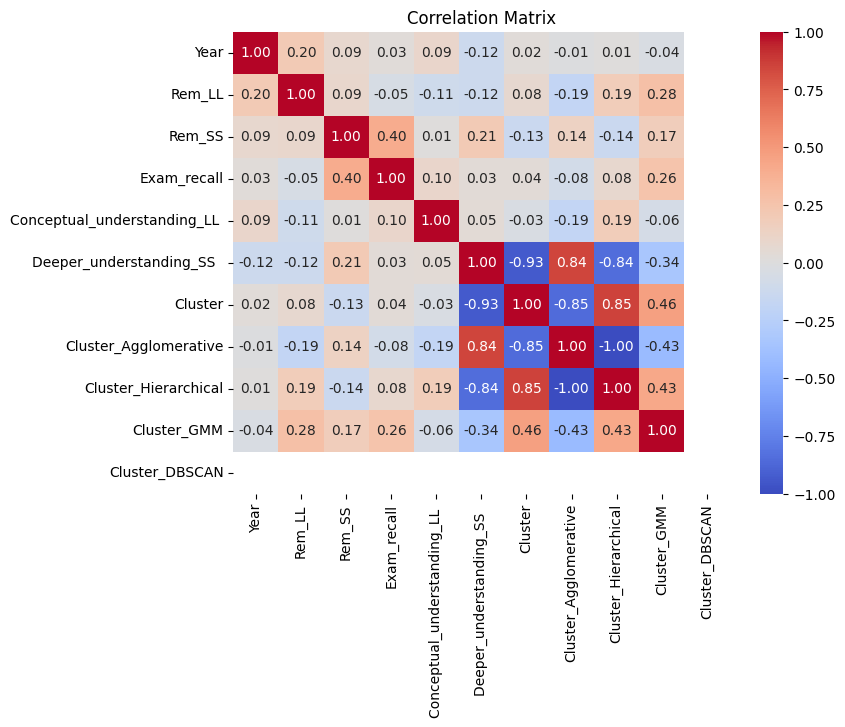

In [ ]:
# Correlation matrix, including only numerical features
corr_matrix = df.corr(numeric_only=True)


plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

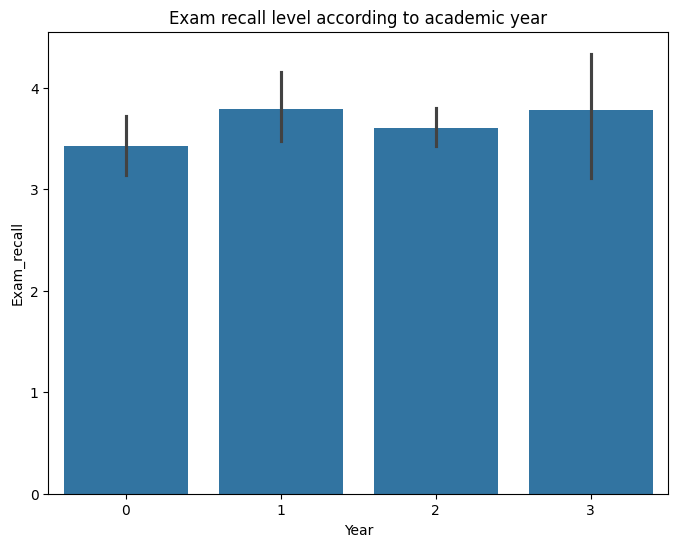

In [ ]:
# Exam recall level according to the academic year
plt.figure(figsize=(8,6))
sns.barplot(x='Year',y='Exam_recall',data=df)
plt.title('Exam recall level according to academic year')
plt.show()

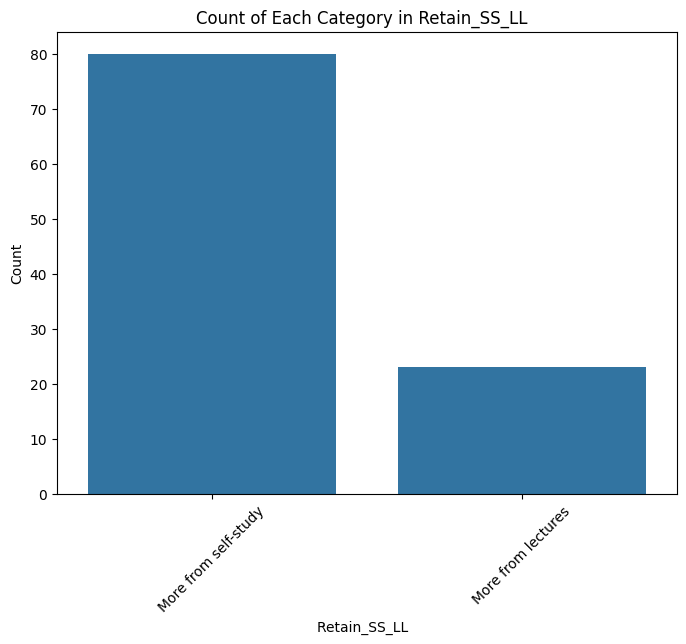

In [ ]:
# Levels of Retention Methods

def display_univariate_counts(data, column):
    category_counts = data[column].value_counts()

    plt.figure(figsize=(8, 6))
    sns.barplot(x=category_counts.index, y=category_counts.values)
    plt.title(f'Count of Each Category in {column}')
    plt.xlabel(f'{column}')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

display_univariate_counts(data=df, column='Retain_SS_LL  ')


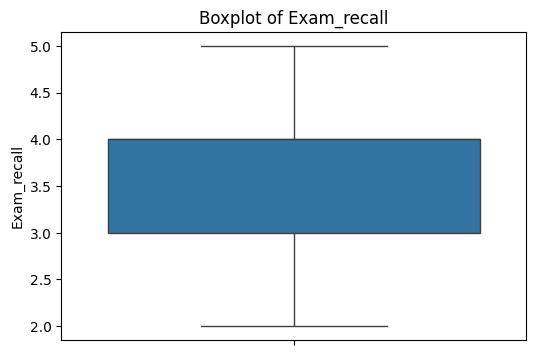

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

column_name = "Exam_recall"

plt.figure(figsize=(6, 4))
sns.boxplot(y=df[column_name])

# Customize plot
plt.title(f"Boxplot of {column_name}")
plt.ylabel(column_name)
plt.show()


In [ ]:
# Create DataFrame
df = pd.DataFrame(df_encoded)

# Convert True/False to 1/0
df = df.astype(int, errors='ignore')

# Save to CSV file
filename = "preprocessed_dataset.csv"
df.to_csv(filename, index=False)

print(f"Dataset saved as {filename}")

Dataset saved as preprocessed_dataset.csv


In [ ]:
from google.colab import files
files.download(filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Clustering**

In [1]:
# Load the preprocessed dataset
import pandas as pd

preprocessed_data = pd.read_csv('/content/preprocessed_dataset.csv')

# Display the first few rows to check the data
preprocessed_data.head()


,Year,Rem_LL,Rem_SS,Exam_recall,Conceptual_understanding_LL,Deeper_understanding_SS,Faculty_Faculty of Computing,Faculty_Faculty of Engineering,Faculty_Faculty of Humanities and Social Sciences,Faculty_Faculty of Management studies and Commerce,...,Challenge_SS_Lack of focus,Challenge_SS_Lack of motivation,Challenge_SS_Other,Challenge_SS_Time management,Long_term_retention _Listening to lectures,Long_term_retention _Self-study,Combine_LM_SS_Never,Combine_LM_SS_Often,Combine_LM_SS_Rarely,Combine_LM_SS_Sometimes
0,2,3,3,4,1,0,0,0,1,0,...,0,0,0,1,0,0,0,1,0,0
1,2,3,4,5,1,0,0,0,1,0,...,1,0,0,0,0,1,0,1,0,0
2,2,3,5,5,0,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
3,2,3,3,3,2,0,0,0,1,0,...,1,0,0,0,0,1,0,1,0,0
4,2,4,5,4,2,2,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0


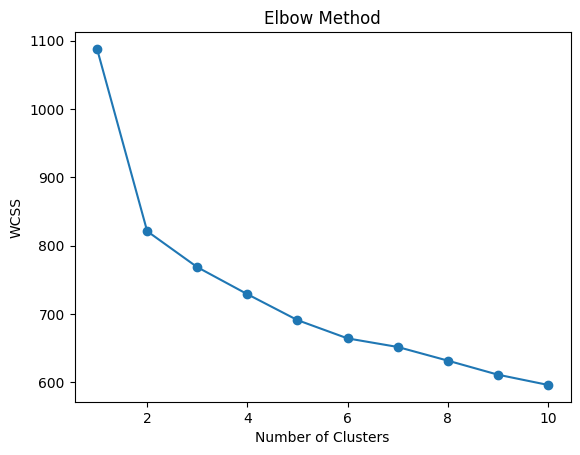

In [ ]:
# Identify Clusters using Elbow Method

# Import Libraries
from sklearn.cluster import KMeans

# Find optimal clusters using the Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(preprocessed_data)
    wcss.append(kmeans.inertia_)

# Plot Elbow Method
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()




In [ ]:
# Silhouette Score for KMeans before PCA
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(preprocessed_data, kmeans.labels_)
print(f"Silhouette Score - KMeans: {kmeans_score:.4f}")



Silhouette Score - KMeans: 0.0540


In [ ]:
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

# Apply PCA to reduce dimensions
pca = PCA(n_components=2)
df_pca = pca.fit_transform(preprocessed_data)

# Re-run K-Means with different cluster numbers
best_k = None
best_kmeans_score = -1

for k in range(2, 6):  # Trying k=2 to k=5
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(preprocessed_data)
    score = silhouette_score(preprocessed_data, clusters)

    print(f"KMeans with k={k}, Silhouette Score: {score:.4f}")

    if score > best_kmeans_score:
        best_kmeans_score = score
        best_k = k

# Apply GMM Clustering
gmm = GaussianMixture(n_components=3, random_state=42)
preprocessed_data['Cluster_GMM'] = gmm.fit_predict(preprocessed_data)
gmm_score = silhouette_score(preprocessed_data, preprocessed_data['Cluster_GMM'])

# Print results
print(f"Best K for K-Means: {best_k}, Silhouette Score: {best_kmeans_score:.4f}")
print(f"Silhouette Score - GMM: {gmm_score:.4f}")




KMeans with k=2, Silhouette Score: 0.2455
KMeans with k=3, Silhouette Score: 0.2267
KMeans with k=4, Silhouette Score: 0.1029
KMeans with k=5, Silhouette Score: 0.1102
Best K for K-Means: 2, Silhouette Score: 0.2455
Silhouette Score - GMM: 0.2069


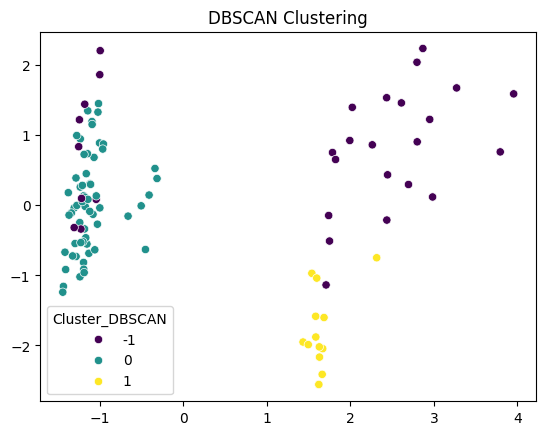

In [ ]:
#DBSCAN Alogorithm

from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA  # Import PCA

dbscan = DBSCAN(eps=3.0, min_samples=5)
preprocessed_data['Cluster_DBSCAN'] = dbscan.fit_predict(preprocessed_data)

# Apply PCA to reduce dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(preprocessed_data)

# Visualizing DBSCAN results using PCA-reduced data
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=preprocessed_data['Cluster_DBSCAN'], palette='viridis')
plt.title("DBSCAN Clustering")
plt.show()

In [ ]:
# Tune DBSCAN parameters
from sklearn.neighbors import NearestNeighbors

# Find optimal eps
nn = NearestNeighbors(n_neighbors=4)
nbrs = nn.fit(preprocessed_data)
distances, _ = nbrs.kneighbors(preprocessed_data)
distances = np.sort(distances[:, -1], axis=0)

# Apply DBSCAN (adjust eps based on knee in plot)
dbscan = DBSCAN(eps=2.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(preprocessed_data)

# Count clusters and noise
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f"DBSCAN Clusters: {n_clusters}, Noise Points: {n_noise}")

# Silhouette Score (excluding noise)
if n_clusters > 1:
    valid_labels = dbscan_labels[dbscan_labels != -1]
    valid_data = preprocessed_data[dbscan_labels != -1]
    print(f"DBSCAN Silhouette Score: {silhouette_score(valid_data, valid_labels):.2f}")
else:
    print("Not enough clusters for Silhouette Score")

DBSCAN Clusters: 2, Noise Points: 77
DBSCAN Silhouette Score: 0.38


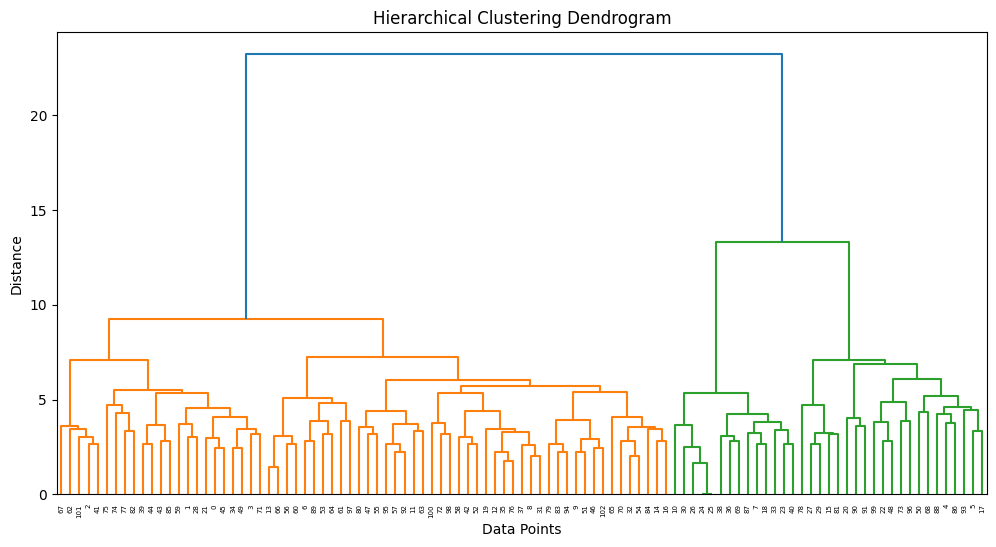

Silhouette Score - Hierarchical Clustering: 0.24816258255025417


In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Create linkage matrix using Ward's method
linked = linkage(preprocessed_data, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()


num_clusters = 2 # Use 2 clusters according to performance
preprocessed_data['Cluster_Hierarchical'] = fcluster(linked, num_clusters, criterion='maxclust')

# Evaluate using Silhouette Score
from sklearn.metrics import silhouette_score

hierarchical_score = silhouette_score(preprocessed_data, preprocessed_data['Cluster_Hierarchical'])
print(f"Silhouette Score - Hierarchical Clustering: {hierarchical_score}")


In [ ]:
# Agglomerative - Hierarchical
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(n_clusters=2)
preprocessed_data['Cluster_Agglomerative'] = agglo.fit_predict(preprocessed_data)

# Evaluate the performance
agglo_score = silhouette_score(preprocessed_data, preprocessed_data['Cluster_Agglomerative'])
print(f"Silhouette Score - Agglomerative Clustering: {agglo_score}")

Silhouette Score - Agglomerative Clustering: 0.24063681583148888


In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# Fit GMM and predict cluster labels
gmm = GaussianMixture(n_components=2, random_state=42)
gmm_labels = gmm.fit_predict(preprocessed_data)

# Evaluate using Silhouette Score
gmm_silhouette = silhouette_score(preprocessed_data, gmm_labels)
print(f"GMM Silhouette Score: {gmm_silhouette}")

# Add the cluster labels to the dataset
preprocessed_data['GMM_Cluster'] = gmm_labels

GMM Silhouette Score: 0.23820027672828128


In [ ]:
from sklearn.cluster import SpectralClustering

# Fit Spectral Clustering
spectral = SpectralClustering(n_clusters=3, affinity='nearest_neighbors', random_state=42)
spectral_labels = spectral.fit_predict(preprocessed_data)

# Evaluate using Silhouette Score
spectral_silhouette = silhouette_score(preprocessed_data, spectral_labels)
print(f"Spectral Clustering Silhouette Score: {spectral_silhouette}")

# Add the cluster labels to the dataset
preprocessed_data['Spectral_Cluster'] = spectral_labels

Spectral Clustering Silhouette Score: 0.2204250073390514


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


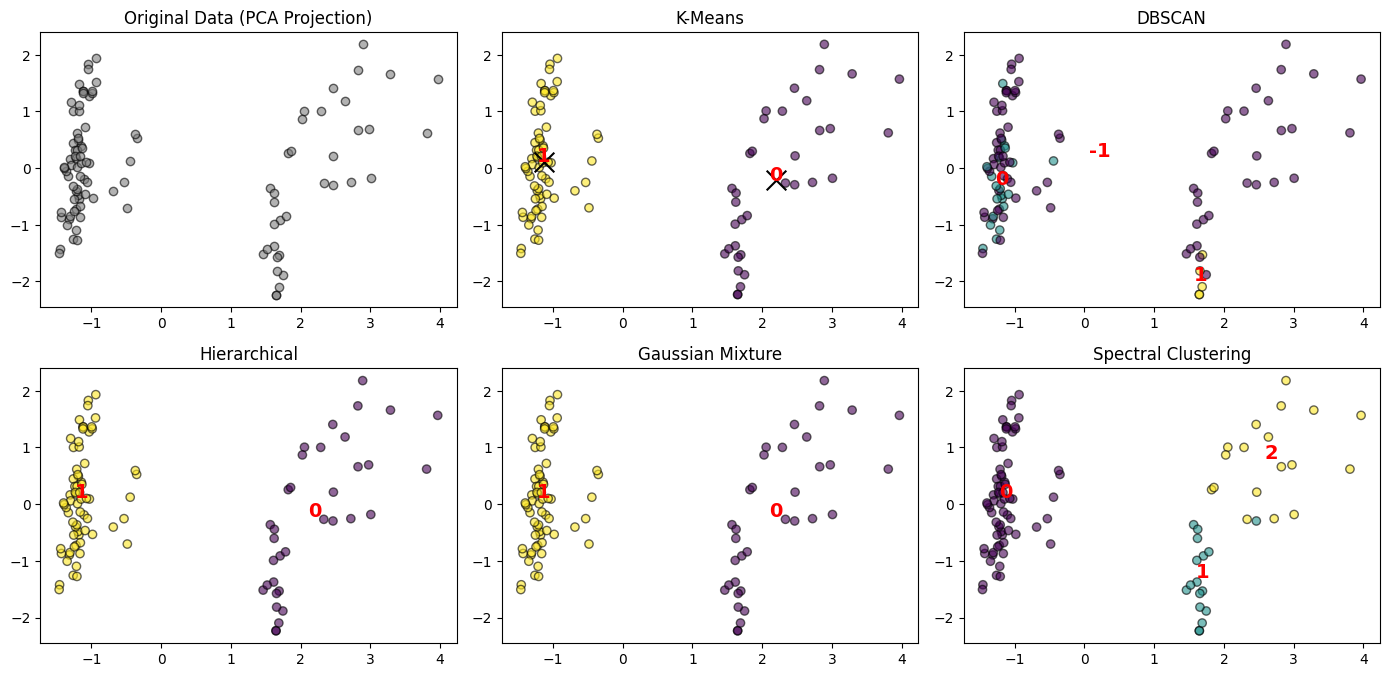

In [ ]:
from sklearn.cluster import KMeans, MeanShift, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

# Reduce dimensions using PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(preprocessed_data)  # Apply PCA to dataset

# Define clustering models
models = {
    "K-Means": KMeans(n_clusters=2, random_state=42),
    "DBSCAN": DBSCAN(eps=2.5, min_samples=5),
    "Hierarchical": AgglomerativeClustering(n_clusters=2),
    "Gaussian Mixture": GaussianMixture(n_components=2, random_state=42),
     "Spectral Clustering": SpectralClustering(n_clusters=3, affinity='nearest_neighbors', random_state=42)
}

# Plot original data using PCA projection
plt.figure(figsize=(14, 10))
plt.subplot(3, 3, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='gray', alpha=0.6, edgecolors='k')
plt.title("Original Data (PCA Projection)")

# Apply and visualize clustering results
for i, (name, model) in enumerate(models.items(), 2):
    clusters = model.fit_predict(preprocessed_data)

    plt.subplot(3, 3, i)
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6, edgecolors='k')

    # Annotate each cluster with a number
    cluster_labels = np.unique(clusters)
    for label in cluster_labels:
        cluster_center = X_pca[clusters == label].mean(axis=0)  # Compute cluster center
        plt.text(cluster_center[0], cluster_center[1], str(label), fontsize=14, fontweight='bold', color='red', ha='center')

    # Plot cluster centers for K-Means and Mean-Shift
    if hasattr(model, 'cluster_centers_'):
        centers_pca = pca.transform(model.cluster_centers_)
        plt.scatter(centers_pca[:, 0], centers_pca[:, 1], marker='x', s=200, c='black', label="Centers")

    plt.title(name)

plt.tight_layout()
plt.show()
